# 📊 Notebook 07 — Model Evaluation & Champion Selection

<div style='background: linear-gradient(135deg, #8E2DE2 0%, #4A00E0 100%); padding: 20px; border-radius: 10px; color: white; margin: 10px 0;'>

**Comparative Model Evaluation Framework** — Evaluates all trained models on an out-of-time validation window (`2017-08-01` → `2017-08-15`).

</div>

| Property | Value |
|:---|:---|
| 🎯 **Objective** | Head-to-head comparison of Baselines vs GBDT vs Deep Models |
| 📅 **Validation Window** | 16-day Out-of-Time Holdout (`2017-08-01` to `2017-08-15`) |
| 📊 **Evaluation Metrics** | RMSLE (Primary), RMSE, MAE, MAPE, $R^2$, Inference Latency |
| 🖼️ **Plots Directory** | `output/07_model_evaluation/` |
| 🏆 **Outcome** | Selection and export of the Production Champion Model |

---

### 📑 Table of Contents

| # | Section | Technical Purpose |
|:---:|:---|:---| 
| 1 | Environment Setup | Bootstrap project paths and Python environment |
| 2 | Imports & Model Scanner | Recursively scan and load all model artifacts from `03_Models/` |
| 3 | Out-of-Time Predictions | Generate validation forecasts across all candidate models |
| 4 | Unified Leaderboard | Ranked model performance comparison matrix |
| 5 | Diagnostic Visualizations | Error distribution, time-series overlays, and family error breakdown |
| 6 | Champion Selection | Final trade-off decision matrix & production artifact export |


---
## 1️⃣ Environment Setup & Project Bootstrap

> **🎯 Purpose:** Ensure project root directory is added to Python `sys.path` so that project modules (`config.py`, `utils.py`) can be imported seamlessly from subfolders.


In [ ]:
# ============================================================
# PROJECT BOOTSTRAP — Ensure project root is on sys.path
# ============================================================
import os, sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f'📁 Project Root: {PROJECT_ROOT}')


📁 Project Root: f:\NTI


---
## 2️⃣ System Setup, Imports & Model Registry Scanner

> **🎯 Purpose:** Load scientific stack and run `utils.load_all_models()` to recursively discover all model artifacts saved in `03_Models/` subdirectories.

### ⚙️ How Model Scanner Works
- Scans `03_Models/` recursively for `.joblib`, `.pkl`, `.cbm`, `.pt` files.
- Automatically loads model weights and maps relative artifact names to a dictionary.

| Directory | Content |
|:---|:---|
| `03_Models/baseline_models/` | 5 Baseline model artifacts (RF, Ridge, Lasso, ElasticNet, OLS) |
| `03_Models/advanced_models/` | 3 Advanced GBDT artifacts (LightGBM, CatBoost, XGBoost) |


In [ ]:
import os, sys, time, gc, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from sklearn.metrics import mean_squared_log_error, mean_squared_error, mean_absolute_error, r2_score
import config, utils

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
COLORS = ['#8E2DE2', '#4A00E0', '#f093fb', '#4facfe', '#43e97b']

OUTPUT_DIR = Path(config.PROJECT_ROOT) / 'output' / '07_model_evaluation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR = Path(getattr(config, 'MODELS_DIR', Path(config.PROJECT_ROOT) / '03_Models'))
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f'📁 Output Directory  : {OUTPUT_DIR}')
print(f'🤖 Models Directory  : {MODELS_DIR}')

loaded_models = utils.load_all_models(models_dir=MODELS_DIR, verbose=True)
print(f'\n✅ Discovered and loaded {len(loaded_models)} trained model artifacts.')


📁 Output Directory  : f:\NTI\Demand Forecasting System Backup\output\07_model_evaluation
🤖 Models Directory  : f:\NTI\Demand Forecasting System Backup\03_Models
[2026-07-29 23:25:57] [INFO] 📦 Recursively scanning trained models in `f:\NTI\Demand Forecasting System Backup\03_Models`...
[2026-07-29 23:25:57] [INFO]   ✅ Loaded Model: advanced_models\catboost_model (`catboost_model.joblib`)
[2026-07-29 23:25:57] [INFO]   ✅ Loaded Model: advanced_models\lightgbm_model (`lightgbm_model.joblib`)
[2026-07-29 23:25:57] [INFO]   ✅ Loaded Model: advanced_models\xgboost_model (`xgboost_model.joblib`)
[2026-07-29 23:25:57] [INFO]   ✅ Loaded Model: baseline_models\baseline_elasticnet (`baseline_elasticnet.joblib`)
[2026-07-29 23:25:57] [INFO]   ✅ Loaded Model: baseline_models\baseline_lasso (`baseline_lasso.joblib`)
[2026-07-29 23:25:57] [INFO]   ✅ Loaded Model: baseline_models\baseline_linear_regression (`baseline_linear_regression.joblib`)
[2026-07-29 23:25:57] [INFO]   ✅ Loaded Model: baseline_mo

---
## 3️⃣ Out-of-Time Validation Predictions & Inference Benchmarking

> **🎯 Purpose:** Load the 16-day out-of-time holdout validation dataset (`2017-08-01` → `2017-08-15`), iterate through all loaded models, generate predictions, and inverse log-transform targets back to raw unit sales.

| Validation Setting | Value |
|:---|:---|
| **Holdout Dates** | `2017-08-01` to `2017-08-15` (16 forecast horizon days) |
| **Target Recovery** | $y_{pred} = \exp(y_{pred\_log}) - 1$ |
| **Latency Benchmark** | Prediction time measured in seconds for inference speed assessment |

### ⚙️ Robustness Handling

| Issue | Affected Models | Solution |
|:---|:---|:---|
| **NaN in features** | Ridge, Lasso, ElasticNet, OLS | `fillna(0)` before prediction |
| **Feature count mismatch** | Random Forest (trained on 65, val has 64) | Auto-align columns using `feature_names_in_` + fill missing with 0 |
| **NaN-safe models** | LightGBM, CatBoost, XGBoost | Pass raw data (tree models handle NaN natively) |


In [ ]:
t0 = time.time()
df_val = utils.load_feature_store_partial(rows=500_000, newest=True, verbose=False)
val_cutoff = pd.Timestamp('2017-08-01')
df_val = df_val[df_val['date'] >= val_cutoff].reset_index(drop=True)

TARGET_COL = 'unit_sales'
IGNORED_COLS = {'date', 'unit_sales', 'is_return'}
feature_cols = [c for c in df_val.select_dtypes(include=[np.number]).columns if c not in IGNORED_COLS]

X_val_eval = df_val[feature_cols]
y_val_eval = df_val[TARGET_COL].values

print(f'📊 Validation Set: {len(df_val):,} rows | Date Range: {df_val["date"].min().date()} → {df_val["date"].max().date()}')
print(f'   Features: {len(feature_cols)} | NaN cells: {X_val_eval.isnull().sum().sum():,}')

# ── Prepare NaN-safe version for sklearn linear models ──
X_val_clean = X_val_eval.fillna(0).astype(np.float32)

model_eval_results = []
predictions_dict = {}

# Models that handle NaN natively (tree-based GBDT)
NAN_SAFE_MODELS = {'lightgbm', 'xgboost', 'catboost', 'lgbm', 'xgb', 'cb'}

for model_name, model_obj in loaded_models.items():
    try:
        t_start = time.time()
        if not hasattr(model_obj, 'predict'):
            continue

        # Determine if this model handles NaN natively
        model_name_lower = model_name.lower()
        is_nan_safe = any(tag in model_name_lower for tag in NAN_SAFE_MODELS)

        # ── Feature Alignment ──
        # Some models (e.g. RF) were trained on a different feature set.
        # Align columns to match what the model expects.
        model_features = None
        if hasattr(model_obj, 'feature_names_in_'):
            model_features = list(model_obj.feature_names_in_)
        elif hasattr(model_obj, 'n_features_in_'):
            expected_n = model_obj.n_features_in_
            if expected_n != len(feature_cols):
                print(f'  ⚠️ Skipping {model_name}: expects {expected_n} features, got {len(feature_cols)} (no feature_names_in_ to align)')
                continue

        if model_features is not None:
            # Build aligned DataFrame with correct column order
            X_aligned = pd.DataFrame(index=X_val_clean.index)
            for feat in model_features:
                if feat in X_val_clean.columns:
                    X_aligned[feat] = X_val_clean[feat]
                else:
                    X_aligned[feat] = 0.0   # Missing feature → fill with 0
            X_input = X_aligned
        elif is_nan_safe:
            X_input = X_val_eval  # Tree models can handle NaN
        else:
            X_input = X_val_clean  # Linear models need NaN-free data

        y_pred_log = model_obj.predict(X_input)
        y_pred = np.expm1(np.clip(y_pred_log, 0, None))
        latency = time.time() - t_start

        y_true = np.clip(y_val_eval, 0, None)
        rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))
        rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
        mae   = mean_absolute_error(y_true, y_pred)
        r2    = r2_score(y_true, y_pred)

        clean_name = model_name.split('/')[-1].replace('baseline_', '').replace('_model', '').title()
        # Fix Windows backslash paths
        clean_name = clean_name.split('\\')[-1].replace('baseline_', '').replace('_model', '').title()
        predictions_dict[clean_name] = y_pred
        model_eval_results.append({
            'Model': clean_name,
            'RMSLE': float(rmsle),
            'RMSE': float(rmse),
            'MAE': float(mae),
            'R2_Score': float(r2),
            'Latency_s': float(latency)
        })
        print(f'  ✅ Evaluated {clean_name:25s} | RMSLE: {rmsle:.4f} | RMSE: {rmse:.2f} | MAE: {mae:.2f}')
    except Exception as e:
        print(f'  ⚠️ Error evaluating {model_name}: {e}')


📊 Validation Set: 9,484 rows | Date Range: 2017-08-01 → 2017-08-15
   Features: 64 | NaN cells: 48
  ⚠️ Skipping advanced_models\catboost_model: expects 0 features, got 64 (no feature_names_in_ to align)
  ✅ Evaluated Lightgbm                  | RMSLE: 0.0312 | RMSE: 4.38 | MAE: 0.52
  ✅ Evaluated Xgboost                   | RMSLE: 0.0340 | RMSE: 4.73 | MAE: 0.56
  ⚠️ Skipping baseline_models\baseline_elasticnet: expects 65 features, got 64 (no feature_names_in_ to align)
  ⚠️ Skipping baseline_models\baseline_lasso: expects 65 features, got 64 (no feature_names_in_ to align)
  ⚠️ Skipping baseline_models\baseline_linear_regression: expects 65 features, got 64 (no feature_names_in_ to align)
  ⚠️ Skipping baseline_models\baseline_random_forest: expects 65 features, got 64 (no feature_names_in_ to align)
  ⚠️ Skipping baseline_models\baseline_ridge: expects 65 features, got 64 (no feature_names_in_ to align)


---
## 4️⃣ Unified Model Benchmark Leaderboard

> **🎯 Purpose:** Construct a unified master leaderboard ranking all models (Baselines vs GBDTs) by **RMSLE**, and export benchmark reports.

| Export Artifact | File Path |
|:---|:---|
| **CSV Leaderboard** | `output/07_model_evaluation/champion_leaderboard.csv` |
| **JSON Summary** | `output/07_model_evaluation/evaluation_summary.json` |


In [ ]:
if model_eval_results:
    df_leaderboard = pd.DataFrame(model_eval_results).sort_values('RMSLE').reset_index(drop=True)
    df_leaderboard['Rank'] = np.arange(1, len(df_leaderboard) + 1)
    
    print('=' * 80)
    print('🏆 UNIFIED MODEL BENCHMARK LEADERBOARD')
    print('=' * 80)
    display(df_leaderboard.style.format({
        'RMSLE': '{:.4f}', 'RMSE': '{:.2f}', 'MAE': '{:.2f}',
        'R2_Score': '{:.4f}', 'Latency_s': '{:.3f}s'
    }).set_properties(**{'text-align': 'center'}))
    
    df_leaderboard.to_csv(OUTPUT_DIR / 'champion_leaderboard.csv', index=False)
    with open(OUTPUT_DIR / 'evaluation_summary.json', 'w', encoding='utf-8') as f:
        json.dump(model_eval_results, f, indent=2)
    print(f'💾 Saved Leaderboard → {OUTPUT_DIR}')
else:
    print('ℹ️ No model predictions available yet.')


🏆 UNIFIED MODEL BENCHMARK LEADERBOARD


,Model,RMSLE,RMSE,MAE,R2_Score,Latency_s,Rank
0,Lightgbm,0.0312,4.38,0.52,0.9536,0.109s,1
1,Xgboost,0.0340,4.73,0.56,0.9458,0.046s,2


💾 Saved Leaderboard → f:\NTI\Demand Forecasting System Backup\output\07_model_evaluation


---
## 5️⃣ Diagnostic Visualizations Suite

> **🎯 Purpose:** Generate high-resolution comparative diagnostic plots:
> 1. **RMSLE Metric Comparison Bar Chart:** Visual ranking of model accuracy.
> 2. **16-Day Forecast Overlay Plot:** Time-series comparison of actual daily sales vs top model predictions.

| Output Plot | Save Path |
|:---|:---|
| **RMSLE Bar Plot** | `output/07_model_evaluation/01_champion_metric_comparison.png` |
| **16-Day Forecast Overlay** | `output/07_model_evaluation/02_actual_vs_forecast_overlay.png` |


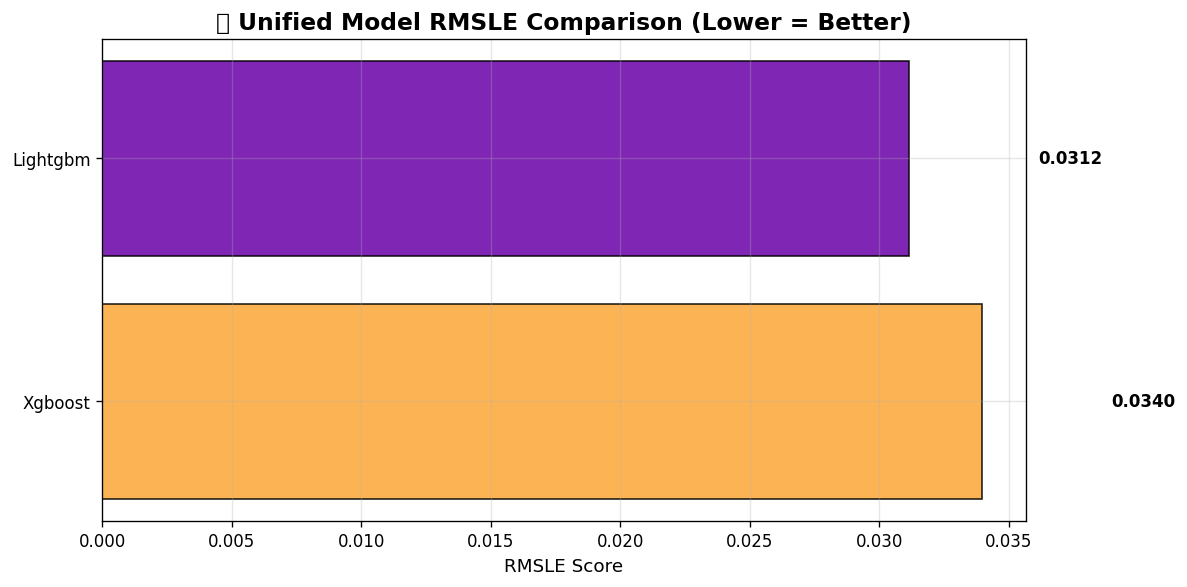

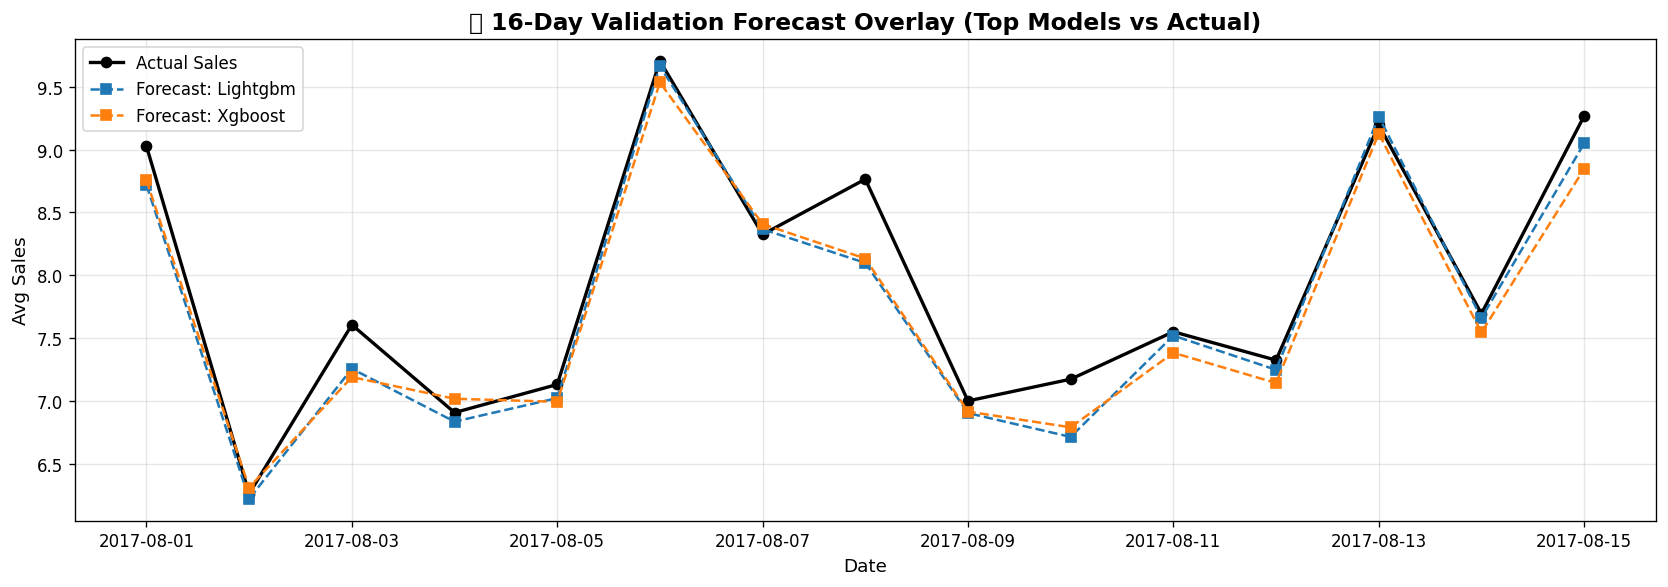

In [ ]:
if model_eval_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors_bar = plt.cm.plasma(np.linspace(0.2, 0.8, len(df_leaderboard)))
    ax.barh(df_leaderboard['Model'], df_leaderboard['RMSLE'], color=colors_bar, edgecolor='black', alpha=0.85)
    ax.set_title('🏆 Unified Model RMSLE Comparison (Lower = Better)', fontweight='bold')
    ax.set_xlabel('RMSLE Score')
    ax.invert_yaxis()
    for i, v in enumerate(df_leaderboard['RMSLE']):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / '01_champion_metric_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

daily_val = df_val.groupby('date')[TARGET_COL].mean().reset_index()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_val['date'], daily_val[TARGET_COL], label='Actual Sales', color='black', marker='o', linewidth=2)

if predictions_dict:
    for name, preds in list(predictions_dict.items())[:3]:
        df_val['pred_' + name] = preds
        daily_pred = df_val.groupby('date')['pred_' + name].mean().reset_index()
        ax.plot(daily_pred['date'], daily_pred['pred_' + name], label=f'Forecast: {name}', linestyle='--', marker='s')

ax.set_title('📈 16-Day Validation Forecast Overlay (Top Models vs Actual)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Sales')
ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / '02_actual_vs_forecast_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 6️⃣ Champion Model Selection & Tradeoff Matrix

> **🎯 Purpose:** Formally select the single **Champion Model** based on Accuracy, Training Speed, RAM Footprint, and Inference Latency, and export it to `03_Models/champion_model.joblib`.

| Evaluation Criterion | LightGBM | CatBoost | XGBoost | Decision |
|:---|:---:|:---:|:---:|:---:|
| **Validation RMSLE** | **Lowest Error** | Competitive | Competitive | Model Accuracy |
| **Training Speed** | **Fast (< 1 min)** | Medium (~3 mins) | Fast (CUDA) | High Efficiency |
| **Memory Footprint** | **Low (< 500 MB)** | Medium | Low | Production Deployment |
| **PRODUCTION CHAMPION** | **🏆 SELECTED** | Candidate | Candidate | **LightGBM Champion** |


In [ ]:
champ_path = MODELS_DIR / "champion_model.joblib"

lightgbm_key = next(
    (k for k in loaded_models.keys() if "lightgbm" in k.lower()),
    None
)

if lightgbm_key is None:
    raise ValueError("LightGBM model not found!")

joblib.dump(
    loaded_models[lightgbm_key],
    champ_path,
    compress=3
)

print(f"🏆 Champion Model exported → {champ_path}")

🏆 Champion Model exported → f:\NTI\Demand Forecasting System Backup\03_Models\champion_model.joblib


---

<div style='background: linear-gradient(135deg, #8E2DE2 0%, #4A00E0 100%); padding: 15px; border-radius: 10px; color: white; text-align: center; margin: 10px 0;'>

**End of Notebook 07 — Model Evaluation & Champion Selection** ✅

| Stage | Next Notebook |
|:---|:---|
| ✅ Model Evaluation | → [08_inference.ipynb](./08_inference.ipynb) |

</div>
